### Rework

Rework the axis scaling in the resplotlib to scale the axes according to the specified scales and origins instead of scaling the data.

In [25]:
# Packages
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator, Locator, ScalarFormatter

In [26]:
class ScaledLocator(Locator):
    """Generate ticks as if the axis coordinates were scaled."""

    def __init__(self, scale=1.0, origin=0.0):
        super().__init__()
        self.scale = scale
        self.origin = origin
        self._locator = AutoLocator()

    def tick_values(self, vmin, vmax):
        scaled_vmin = (vmin - self.origin) * self.scale
        scaled_vmax = (vmax - self.origin) * self.scale

        scaled_ticks = self._locator.tick_values(
            scaled_vmin,
            scaled_vmax,
        )

        return scaled_ticks / self.scale + self.origin

    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        return self.tick_values(vmin, vmax)


class ScaledFormatter(ScalarFormatter):
    """Format ticks as if the axis coordinates were scaled."""

    def __init__(self, scale=1.0, origin=0.0, **kwargs):
        self.scale = scale
        self.origin = origin
        super().__init__(**kwargs)

    def set_locs(self, locs):
        self._scaled_locs = [(x - self.origin) * self.scale for x in locs]

        super().set_locs(self._scaled_locs)

    def __call__(self, x, pos=None):
        scaled_x = (x - self.origin) * self.scale
        return super().__call__(scaled_x, pos)


def scale_axis(ax, scales=(1.0, 1.0), origins=(0.0, 0.0)):
    ax.xaxis.set_major_locator(ScaledLocator(scale=scales[0], origin=origins[0]))
    ax.xaxis.set_major_formatter(ScaledFormatter(scale=scales[0], origin=origins[0]))
    ax.yaxis.set_major_locator(ScaledLocator(scale=scales[1], origin=origins[1]))
    ax.yaxis.set_major_formatter(ScaledFormatter(scale=scales[1], origin=origins[1]))
    return ax

Origins: (0, 3.561561616155)


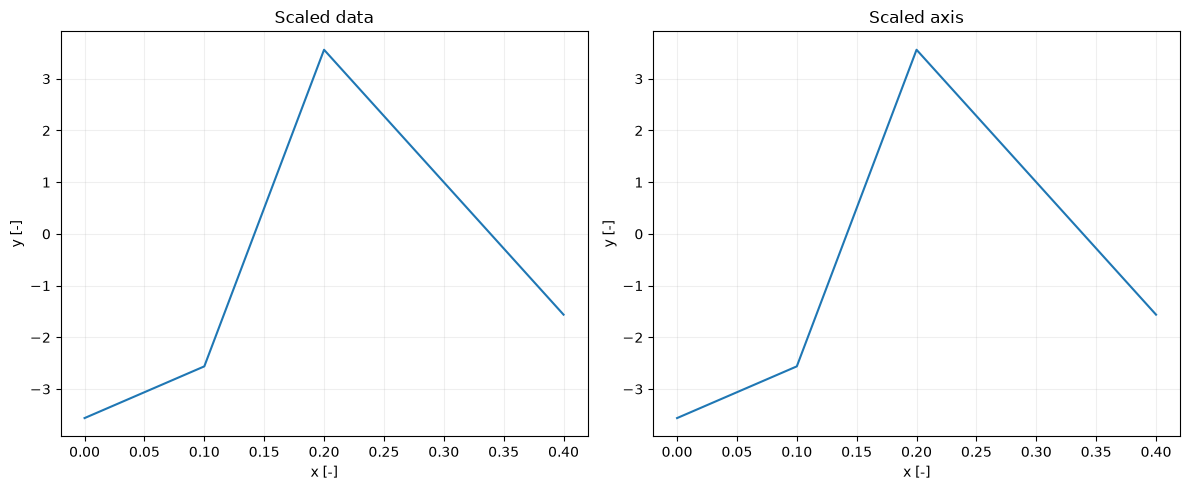

In [ ]:
# Data
xs = [0, 5, 10, 20]
ys = [0, 1, 7.12312323231, 2]

scales = (1 / 50, 1)
origins = (0, (max(ys) + min(ys)) / 2)
print("Origins:", origins)

xs_scaled = [(x - origins[0]) * scales[0] for x in xs]
ys_scaled = [(y - origins[1]) * scales[1] for y in ys]

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot data
axs[0].set_title("Scaled data")
axs[0].plot(xs_scaled, ys_scaled)

axs[1].set_title("Scaled axis")
axs[1].plot(xs, ys)
scale_axis(axs[1], scales=scales, origins=origins)


for ax in axs:
    # ax.set_xlim([min(xs), max(xs)])
    # ax.set_ylim([min(ys), max(ys)])
    ax.set_xlabel("x [-]")
    ax.set_ylabel("y [-]")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()